In [1]:
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import cartopy
import cartopy.crs as ccrs
import os
import pickle
from regrid import regrid
import datetime
from scipy.stats import linregress

/home/robbie/anaconda3/envs/algae/lib/python3.13/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


Pond Data

https://data.seaice.uni-bremen.de/MeltPonds-Albedo/MPD2/7-day/netcdf/2022/

NSIDC Grid Data

https://daacdata.apps.nsidc.org/pub/DATASETS/nsidc0771_polarstereo_anc_grid_info/

https://nsidc.org/data/nsidc-0771/versions/1

SIC Data

https://nsidc.org/data/nsidc-0051/versions/2#anchor-data-access-tools

https://cmr.earthdata.nasa.gov/virtual-directory/collections/C3177837840-NSIDC_CPRD/temporal/2022/08/14

In [2]:
conc_files = sorted(os.listdir('../SIC'))
conc_files

['Funding, Fellowships, Events and Training for ECRs including PhDs -September 2025.pdf',
 'NSIDC0051_SEAICE_PS_N25km_20220729_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220730_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220731_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220801_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220802_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220803_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220804_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220805_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220806_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220807_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220808_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220809_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220810_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220811_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220812_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220813_v2.0.nc',
 'NSIDC0051_SEAICE_PS_N25km_20220814_v2.0.nc']

In [3]:
conc_d = Dataset(f'../SIC/{conc_files[-1]}')
conc_lonlat = Dataset('../aux_data/NSIDC0771_LatLon_PS_N25km_v1.1.nc')
conc25 = np.array(conc_d['F17_ICECON'][0])
conc_lon = np.array(conc_lonlat['longitude'])
conc_lat = np.array(conc_lonlat['latitude'])

grid_d = Dataset('../aux_data/NSIDC0771_LatLon_PS_N12.5km_v1.1.nc')
lon,lat=np.array(grid_d['longitude']),np.array(grid_d['latitude'])
lon = np.fliplr(np.rot90(np.rot90(lon)))
lat = np.fliplr(np.rot90(np.rot90(lat)))

conc12s=[]

for f in conc_files:
    conc25 = np.array(conc_d['F17_ICECON'][0])

    conc12 = regrid(conc25,conc_lon,conc_lat,lon,lat)
    
    conc12[conc12>1]=np.nan
    conc12[conc12==0]=np.nan
    conc12s.append(conc12)
len(conc12s)

/tmp/ipykernel_39437/826034291.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  conc_lon = np.array(conc_lonlat['longitude'])
/tmp/ipykernel_39437/826034291.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  conc_lat = np.array(conc_lonlat['latitude'])
/tmp/ipykernel_39437/826034291.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, 

18

### Plot SIC

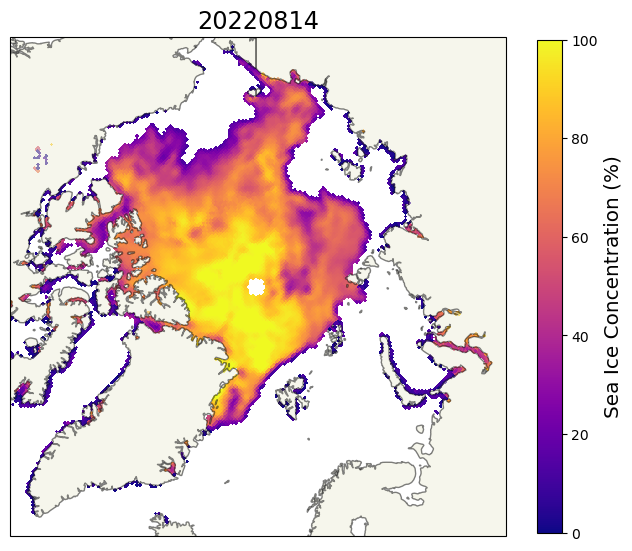

In [4]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)
m = ax.pcolormesh(lon,
                  lat,
                  100*conc12s[-1],
                  vmin = 0,
                  vmax = 100,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

cb=fig.colorbar(m,shrink=0.8)
cb.set_label('Sea Ice Concentration (%)',fontsize='x-large')
ax.set_title(conc_files[-1][-16:-8],fontsize='xx-large')
plt.savefig('../figs/si_conc.png',dpi=500,bbox_inches='tight')

In [104]:
alb_files = [f for f in os.listdir('../ponds') if '.nc' in f]

In [105]:
mean_no_ponds=[]
std_no_ponds=[]
lrs=[]

for i,sic in zip(alb_files,conc12s):
    
    d0=Dataset('../ponds/'+i)
    alb = np.array(d0['alb_ntbc'])
    mpf = 100*np.array(d0['mpf'])

    alb[lat<66]=np.nan
    mpf[lat<66]=np.nan

    mpf[sic<0.1]=np.nan
    alb[sic<0.1]=np.nan

    mean_no_ponds.append( np.nanmean(alb[mpf<0.5]) )
    std_no_ponds.append( np.nanstd(alb[mpf<0.5]) )
    
    mpf[mpf<1]=np.nan
    alb[mpf<1]=np.nan

    

    mp = mpf[~np.isnan(alb)]
    ab = alb[~np.isnan(alb)]
    
    ab = ab[~np.isnan(mp)]
    mp = mp[~np.isnan(mp)]

    lr = linregress(mp,ab)
    lrs.append(lr)

    
    # plt.hexbin(mpf.flatten(),alb.flatten(),mincnt=5)
    # plt.ylim(0,1)
    # plt.xlim(0,30)
    # plt.ylabel('Broadband Albedo',fontsize='x-large')
    # plt.xlabel('Melt Pond Fraction (%)',fontsize='x-large')
    # plt.plot([0,20],[lr[1],lr[1]+lr[0]*20],color='r')
    # plt.show()

/tmp/ipykernel_9416/737056416.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  alb = np.array(d0['alb_ntbc'])
/tmp/ipykernel_9416/737056416.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mpf = 100*np.array(d0['mpf'])


In [89]:
date_ticks = [datetime.date(2022,7,29)+datetime.timedelta(days=int(i)) for i in np.arange(17)]
tick_labels=[str(x)[-4:] for x in date_ticks]

In [ ]:
plt.violinplot(

0.6077148185544847
0.56847537


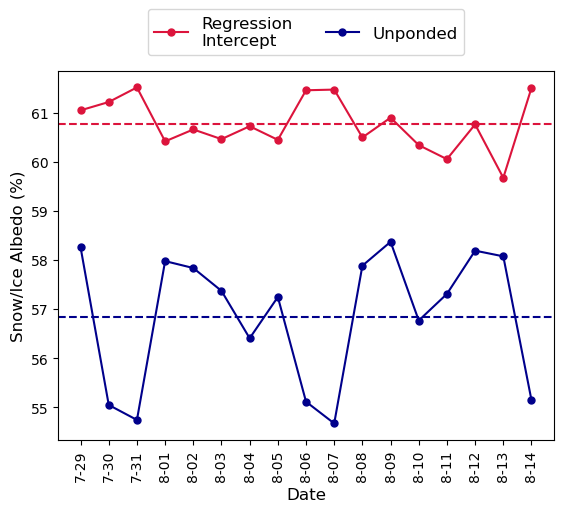

In [108]:
intercepts = np.array([x[1] for x in lrs])
mean_no_ponds=np.array(mean_no_ponds)
std_no_ponds=np.array(std_no_ponds)

plt.plot(date_ticks,100*intercepts,color='crimson',label='Regression\nIntercept',marker='o',markersize=5)
plt.axhline(100*np.nanmean(intercepts),color='crimson',ls='--')
print(np.nanmean(intercepts))
print(np.nanmean(mean_no_ponds))
# plt.errorbar(date_ticks,100*mean_no_ponds,yerr=100*std_no_ponds,color='darkblue',label='Unponded',marker='o',markersize=5)
plt.errorbar(date_ticks,100*mean_no_ponds,color='darkblue',label='Unponded',marker='o',markersize=5)

plt.axhline(100*np.nanmean(mean_no_ponds),ls='--',color='darkblue')
plt.legend(bbox_to_anchor=(0.5,1.02),loc='lower center',fontsize='large',ncols=2)
plt.ylabel('Snow/Ice Albedo (%)',fontsize='large')
plt.xticks(date_ticks,rotation=90,labels=tick_labels)
plt.xlabel('Date',fontsize='large')
plt.savefig('../figs/ice_albedo.png',dpi=500,bbox_inches='tight')
plt.show()